# Mooooodellllll

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
from rapidfuzz import process, fuzz
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Linear
from sklearn.linear_model import (
    Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
)

# Tree / Ensemble
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, AdaBoostRegressor
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from datetime import datetime

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [2]:
def read_sheets(filename):
    """Read the input data"""
    sheets = pd.read_excel(filename, sheet_name=None)
    df = pd.concat(sheets.values(), ignore_index=True)
    return df.shape, df

df_time_shape, df_time = read_sheets("time_card_daily_latest.xlsx")
print(f"Time shape: {df_time_shape}")

df_inc_shape, df_inc = read_sheets("incident since 2024-05-01.xlsx")
print(f"Incidents shape: {df_inc_shape}")

Time shape: (129951, 15)
Incidents shape: (6020, 43)


## ABT Build

In [3]:
def clean_name(name):
    if pd.isna(name):
        return name
    
    if "," in name:
        parts = [p.strip() for p in name.split(",")]
    else:
        parts = [p.strip() for p in name.split(" ")]

    first_name = parts[-1]
    last_name = parts[0]

    if "," in name:
        return f"{first_name} {last_name}".lower()
    else:
        return f"{last_name} {first_name}".lower()

In [4]:
offboarded = pd.read_excel("Resources.xlsx", sheet_name="Offboarded Resources")
offboarded["Offboarded"] = True
active = pd.read_excel("Resources.xlsx", sheet_name="Resource List 20250206")
active["Offboarded"] = False
sheets = [
    active,
    offboarded
          
]
df_staff = pd.concat(sheets, ignore_index=True)
df_staff.drop([
    "Cross checked",
    "Location",
    "In DL",
    "Pod",
    "Email",
    "Gender",
    "Onboarding Done",
    "Source",
    "Seniority",
    "Pod Lead",
    "Nationality",
    "Active"
], axis=1, inplace=True)

In [5]:
df_staff['Name'] = df_staff['Name'].apply(clean_name)
df_staff = df_staff[df_staff['Technology'] != 'ServiceNow']
df_staff = df_staff.sort_values(by="Offboarded", ascending=False)

In [6]:
df_time["User"] = df_time["User"].apply(clean_name)
len(df_time) # before removing GEN

129951

In [7]:
task_types = ["INC", "CHG", "SCT"]

df_time["is_sick_holiday"] = df_time["Category"].isin(["Sick/Holiday"]).astype(int)

df_time = df_time[
    df_time["Task"].str.startswith(tuple(task_types), na=False)
    | df_time["Category"].isin(["Sick/Holiday"])
]

In [8]:
df_time["Category"].value_counts()

Category
Task work       57908
Sick/Holiday     5118
Name: count, dtype: int64

In [9]:
df_time.loc[df_time["is_sick_holiday"] == 1, "Time worked"] = 0

In [10]:
len(df_time)

63026

In [11]:
len(df_staff["Name"].unique())

203

In [12]:
len(df_time["User"].unique())

155

In [13]:
staff_names = df_staff["Name"].tolist()

df_time["closest_match"] = df_time["User"].apply(
    lambda x: process.extractOne(
        x,
        staff_names,
        scorer=fuzz.token_sort_ratio
    )[0] if pd.notna(x) else None
)

In [14]:
len(df_time)

63026

In [15]:
override_map = {
    "klevis dedaj": "None",
    "kim matos": "kim shimabukuro matos",
    "sadri salihu": "None",
    "valentina gonzalez": "None",
    "sarudzai midzi": "None",
    "arena hysi": "None",
    "danka biocanin": "None",
    "chady mattar": "None",
    "alisha kalan": "None",
    "ailsa thompson": "None",
    "michael ogunniyi": "None",
    "snehalata vidhi": "None",
    "sri sai": "None",
    "rina bardoniqi": "None",
    "purvesh kulkarni": "None",
    "ashok bishnoi": "None",
    "richard hims": "None",
    "syedkhurram mehdi": "None",
    "fouziasunder bhatti": "None",
    "clementina buttigieg": "None",
    "robert gauci": "None",
    "purvesh kulkarni": "None",
    "widad elasly": "None"
}

In [16]:
df_time["final_name"] = df_time["closest_match"]

mask = df_time["User"].isin(override_map.keys())
df_time.loc[mask, "final_name"] = df_time.loc[mask, "User"].map(override_map)

In [17]:
mismatches = df_time[df_time["User"] != df_time["final_name"]][["User", "final_name"]]
#mismatches.value_counts()

In [18]:
len(df_time)

63026

In [19]:
df_time["_row_id"] = range(len(df_time))

In [20]:
df_merged = df_time.merge(
    df_staff[["Name", "Allocation to MS", "Date of Joining", "Date of Leaving"]],
    left_on="final_name", right_on="Name", how="left")
df_merged.drop(["closest_match", "User", "Additional comments", "Rate type", "Business Services"], axis=1, inplace=True)
len(df_merged)

63026

In [21]:
dup_expansion = df_merged[df_merged.duplicated("_row_id", keep=False)]

In [22]:
expansion_counts = df_merged["_row_id"].value_counts()
expansion_counts = expansion_counts[expansion_counts > 1]

In [23]:
problem_rows = df_merged[df_merged["_row_id"].isin(expansion_counts.index)]
problem_rows.sort_values("_row_id")

,Date,Task,Short description,Company,Business service,Project ID,Technology,Category,Time worked,Grade,Specialisation,is_sick_holiday,final_name,_row_id,Name,Allocation to MS,Date of Joining,Date of Leaving


In [24]:
df_merged.drop(["Name", "Company", "Short description",
                "Business service", "Project ID", "Grade",
                "_row_id"
], axis=1, inplace=True)
df_merged.head(5)

,Date,Task,Technology,Category,Time worked,Specialisation,is_sick_holiday,final_name,Allocation to MS,Date of Joining,Date of Leaving
0,2024-05-01,INC0027304,Dynamics 365 FO,Task work,1.0,NaN,0,vaibhav vinayak sane,1.0,NaN,NaT
1,2024-05-01,INC0027284,Dynamics 365 FO,Task work,0.5,NaN,0,chiamaka joy ichoku,1.0,NaN,NaT
2,2024-05-01,INC0027321,Dynamics 365 FO,Task work,1.0,NaN,0,vaibhav vinayak sane,1.0,NaN,NaT
3,2024-05-01,INC0027249,Dynamics 365 BC,Task work,2.0,NaN,0,joseph pellicano,1.0,NaN,NaT
4,2024-05-01,NaN,NaN,Sick/Holiday,0.0,NaN,1,nigel vella,0.2,NaT,NaT


## Feature Engineering - Demand 

* Note that the ABT will be different depending on the model. This notebook only contains the DEMAND models.

In [26]:
abt = df_merged.drop(
    ["Task", "Category", "final_name",
     "Allocation to MS", "Date of Joining", "Date of Leaving"], axis=1)
abt.head(3)

,Date,Technology,Time worked,Specialisation,is_sick_holiday
0,2024-05-01,Dynamics 365 FO,1.0,NaN,0
1,2024-05-01,Dynamics 365 FO,0.5,NaN,0
2,2024-05-01,Dynamics 365 FO,1.0,NaN,0


In [27]:
def one_hot_encode(df, columns, drop_first=False, dummy_na=False, dtype="int"):
    df_encoded = pd.get_dummies(
        df,
        columns=columns,
        drop_first=drop_first,
        dummy_na=dummy_na
    )
    dummy_cols = [col for col in df_encoded.columns 
                  if any(col.startswith(f"{c}_") for c in columns)]
    
    df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(dtype)

    return df_encoded


#abt_encoded = one_hot_encode(abt, ["Rate type"], drop_first=False, dummy_na=False)
abt_encoded = abt.copy()
abt_encoded["Date"] = pd.to_datetime(abt_encoded["Date"])
abt_encoded = abt_encoded.sort_values(by="Date", ascending=True)
abt_encoded.head(3)

,Date,Technology,Time worked,Specialisation,is_sick_holiday
0,2024-05-01,Dynamics 365 FO,1.0,NaN,0
28,2024-05-01,Dynamics 365 CE,4.0,NaN,0
29,2024-05-01,NaN,0.0,CE Technical,1


In [28]:
df = abt_encoded.copy()

In [29]:
grouped_dfs = {}

for (spec, tech), group in df.groupby(["Specialisation", "Technology"]):
    key = f"{spec}_{tech}".replace(" ", "_")
    grouped_dfs[key] = group.copy()

In [30]:
def aggregate_df(df, spike_dates=None):

    df["Date"] = pd.to_datetime(df["Date"])

    df["week"] = df["Date"].dt.to_period("W").dt.start_time

    df["week_of_year"] = df["week"].dt.isocalendar().week.astype(int)
    df["month"] = df["week"].dt.month
    df["is_month_end"] = df["week"].dt.is_month_end.astype(int)
    df["is_quarter_end"] = df["week"].dt.is_quarter_end.astype(int)

    if spike_dates is not None:
        spike_dates = pd.to_datetime(spike_dates)
        df["is_spike"] = df["Date"].isin(spike_dates).astype(int)
    else:
        df["is_spike"] = 0

    underscore_cols = [col for col in df.columns if "_" in col]
    underscore_cols = [c for c in underscore_cols if pd.api.types.is_numeric_dtype(df[c])]

    agg_cols = (
        ["Time worked", "is_spike"]
        + underscore_cols
    )
    weekly_df = (
        df.groupby("week")[agg_cols]
        .sum()
        .reset_index()
        .sort_values(by="week", ascending=True)
    )
    weekly_df["week_of_year"] = weekly_df["week"].dt.isocalendar().week.astype(int)
    weekly_df["month"] = weekly_df["week"].dt.month
    weekly_df["is_month_end"] = weekly_df["week"].dt.is_month_end.astype(int)
    weekly_df["is_quarter_end"] = weekly_df["week"].dt.is_quarter_end.astype(int)


    weekly_df = weekly_df[~(
        (weekly_df["week"].dt.year == 2026) &
        (weekly_df["week"].dt.month.isin([6, 7]))
    )]


    return weekly_df

In [31]:
for i in grouped_dfs:
    grouped_dfs[i] = aggregate_df(grouped_dfs[i])

In [32]:
for i in grouped_dfs:
    display(grouped_dfs[i].head(3))

,week,Time worked,is_spike,is_sick_holiday,week_of_year,is_month_end,is_quarter_end,is_spike,month
0,2025-04-07,2.0,0,0,15,0,0,0,4
1,2025-04-14,0.5,0,0,16,0,0,0,4
2,2025-07-14,13.5,0,0,29,0,0,0,7


,week,Time worked,is_spike,is_sick_holiday,week_of_year,is_month_end,is_quarter_end,is_spike,month
0,2025-01-13,25.0,0,0,3,0,0,0,1
1,2025-01-20,37.5,0,0,4,0,0,0,1
2,2025-01-27,13.0,0,0,5,0,0,0,1


,week,Time worked,is_spike,is_sick_holiday,week_of_year,is_month_end,is_quarter_end,is_spike,month
0,2025-11-03,2.5,0,0,45,0,0,0,11
1,2025-11-10,0.5,0,0,46,0,0,0,11
2,2025-11-17,16.0,0,0,47,0,0,0,11


,week,Time worked,is_spike,is_sick_holiday,week_of_year,is_month_end,is_quarter_end,is_spike,month
0,2025-01-13,1.5,0,0,3,0,0,0,1
1,2025-01-20,0.5,0,0,4,0,0,0,1
2,2025-03-03,1.0,0,0,10,0,0,0,3


,week,Time worked,is_spike,is_sick_holiday,week_of_year,is_month_end,is_quarter_end,is_spike,month
0,2025-08-18,6.0,0,0,34,0,0,0,8
1,2025-08-25,15.0,0,0,35,0,0,0,8
2,2026-02-09,1.0,0,0,7,0,0,0,2


...

,week,Time worked,is_spike,is_sick_holiday,week_of_year,is_month_end,is_quarter_end,is_spike,month
0,2025-05-26,4.3,0,0,22,0,0,0,5
1,2025-06-02,4.5,0,0,23,0,0,0,6
2,2025-06-09,2.0,0,0,24,0,0,0,6


,week,Time worked,is_spike,is_sick_holiday,week_of_year,is_month_end,is_quarter_end,is_spike,month
0,2025-07-21,0.30,0,0,30,0,0,0,7
1,2025-11-10,4.05,0,0,46,0,0,0,11
2,2025-11-17,5.00,0,0,47,0,0,0,11


,week,Time worked,is_spike,is_sick_holiday,week_of_year,is_month_end,is_quarter_end,is_spike,month
0,2024-07-08,6.00,0,0,28,0,0,0,7
1,2024-07-15,0.45,0,0,29,0,0,0,7
2,2025-08-18,1.50,0,0,34,0,0,0,8


,week,Time worked,is_spike,is_sick_holiday,week_of_year,is_month_end,is_quarter_end,is_spike,month
0,2024-10-07,0.35,0,0,41,0,0,0,10


,week,Time worked,is_spike,is_sick_holiday,week_of_year,is_month_end,is_quarter_end,is_spike,month
0,2024-07-22,1.2,0,0,30,0,0,0,7
1,2024-07-29,1.2,0,0,31,0,0,0,7


## Model Selection

Azure_Infrastructure_Dynamics_365_CE

Azure_Infrastructure_Dynamics_365_FO | BEST: Ridge | MAPE: 0.72 | MAE: 2.03


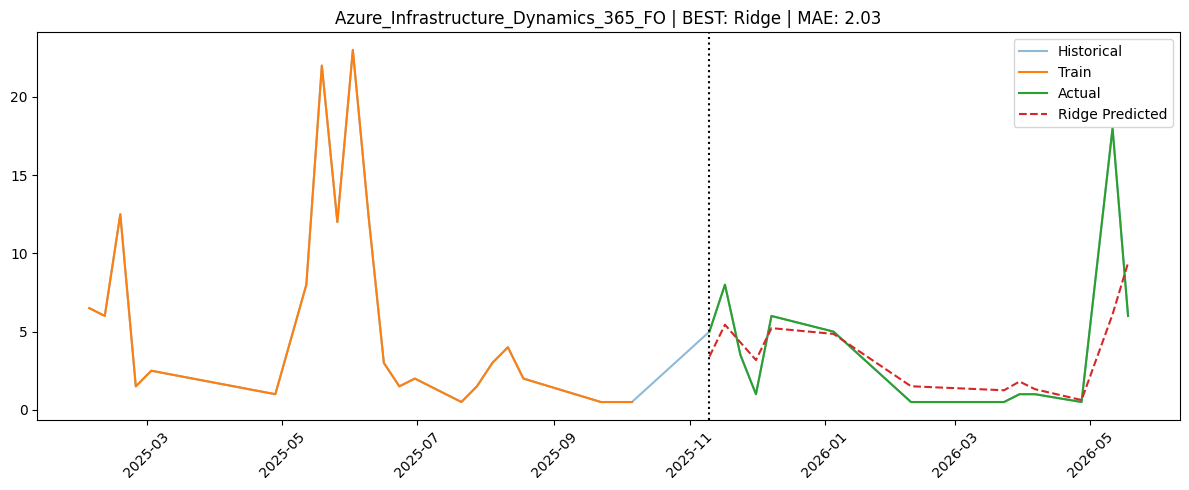

Azure_Infrastructure_Dynamics_NAV
Azure_Infrastructure_Microsoft_Azure
Azure_Infrastructure_Microsoft_Cloud_Data_Warehouse
Azure_Infrastructure_Microsoft_Cloud_Support_Infrastructure
Azure_Integration_Dynamics_365_BC

Azure_Integration_Dynamics_365_CE | BEST: DecisionTree | MAPE: 0.39 | MAE: 3.69


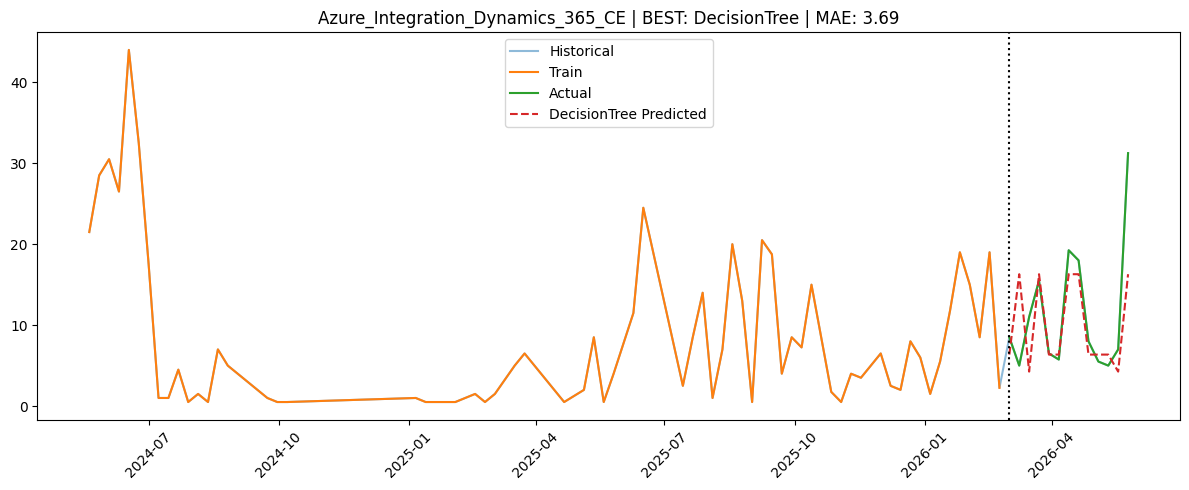


Azure_Integration_Dynamics_365_FO | BEST: Huber | MAPE: 0.19 | MAE: 6.09


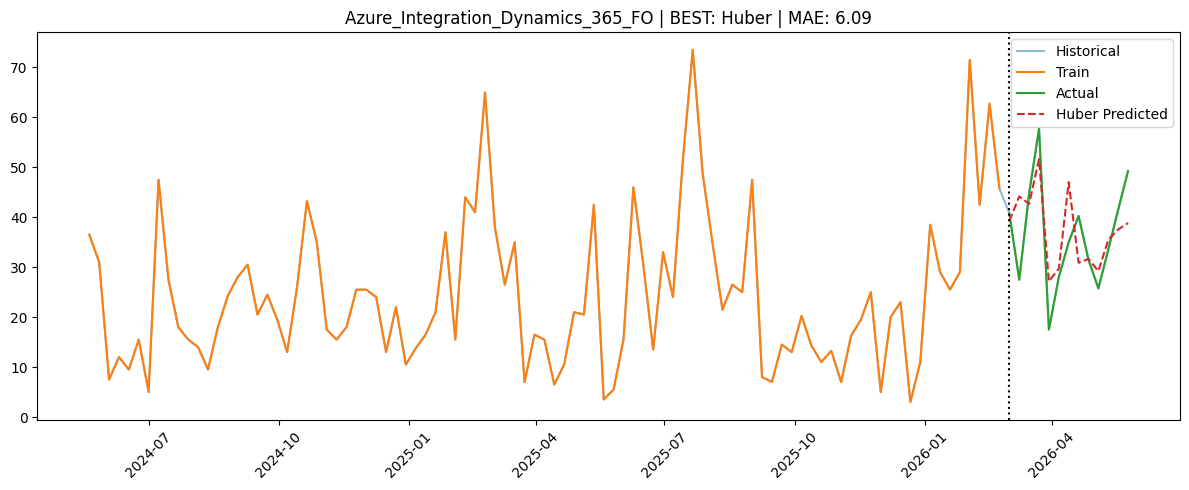


Azure_Integration_Dynamics_365_FSCM | BEST: RandomForest | MAPE: 1.41 | MAE: 1.74


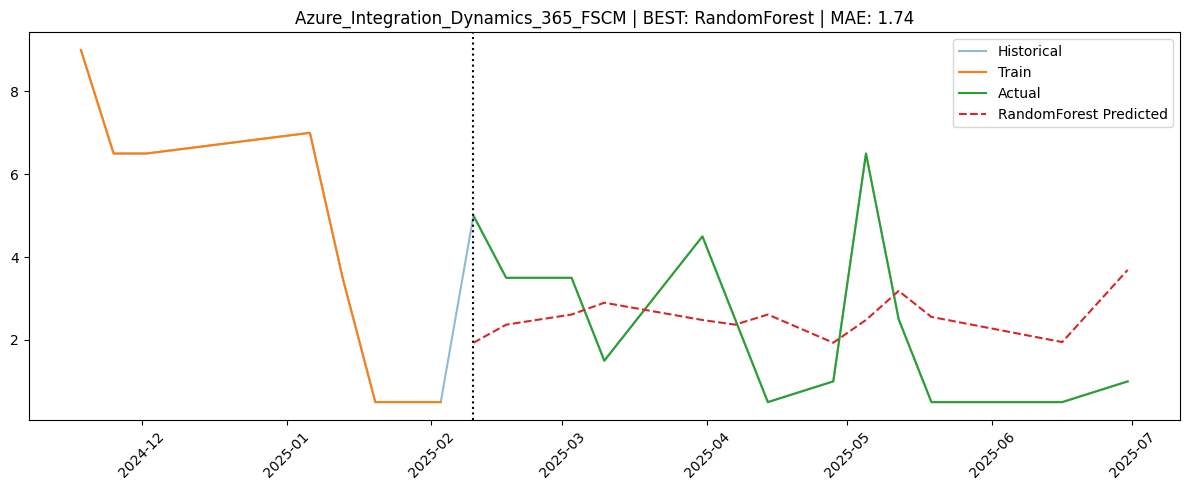


Azure_Integration_Dynamics_NAV | BEST: AdaBoost | MAPE: 1.35 | MAE: 3.48


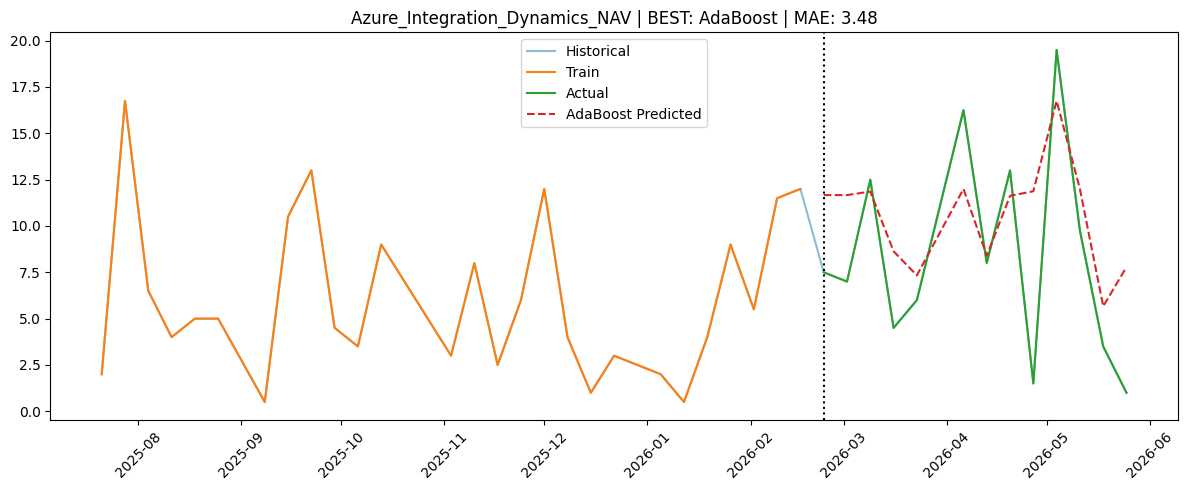


Azure_Integration_Microsoft_Azure | BEST: BayesianRidge | MAPE: 0.23 | MAE: 5.06


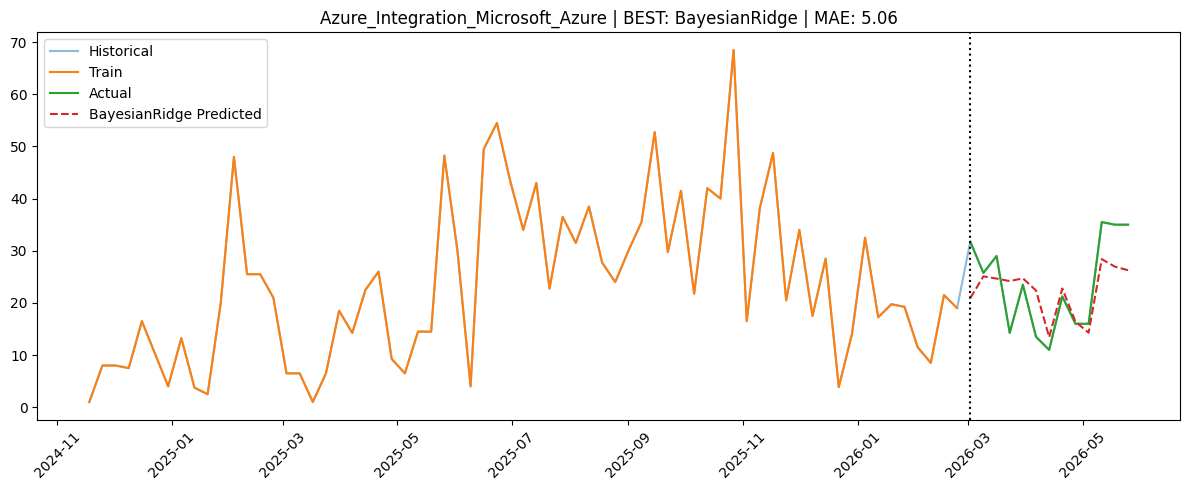

Azure_Integration_Microsoft_Cloud_Data_Warehouse
Azure_Integration_Power_Platform

BC_Technical_Dynamics_365_BC | BEST: GradientBoosting | MAPE: 0.43 | MAE: 3.31


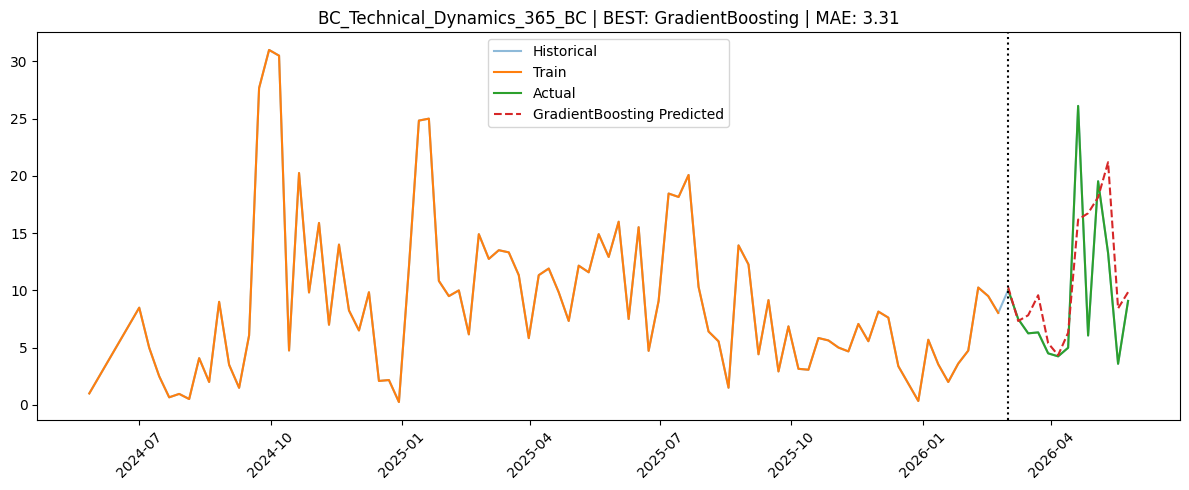


BC_Technical_Dynamics_NAV | BEST: Ridge | MAPE: 0.30 | MAE: 5.54


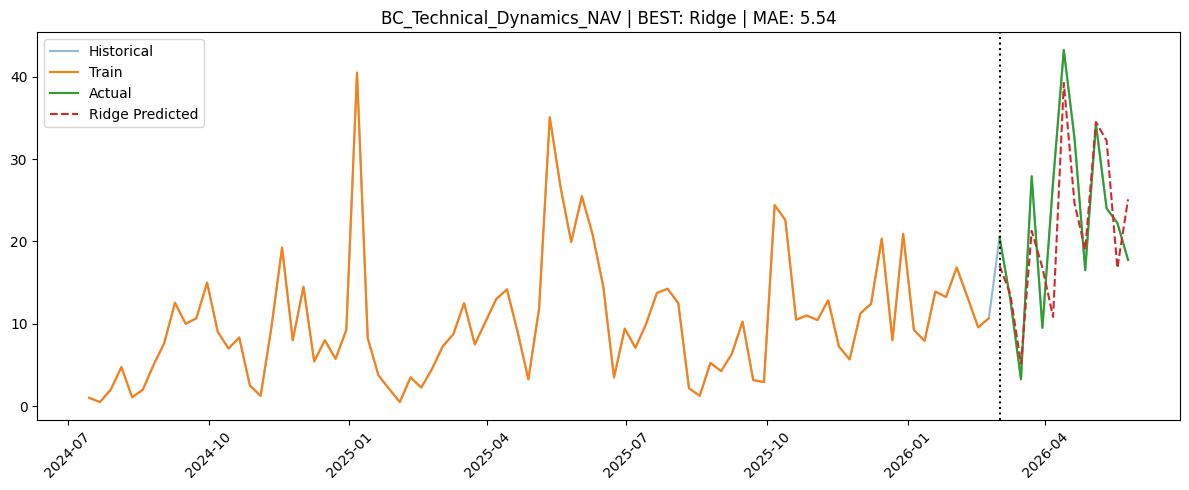


CE_Functional_Dynamics_365_CE | BEST: Ridge | MAPE: 0.26 | MAE: 6.83


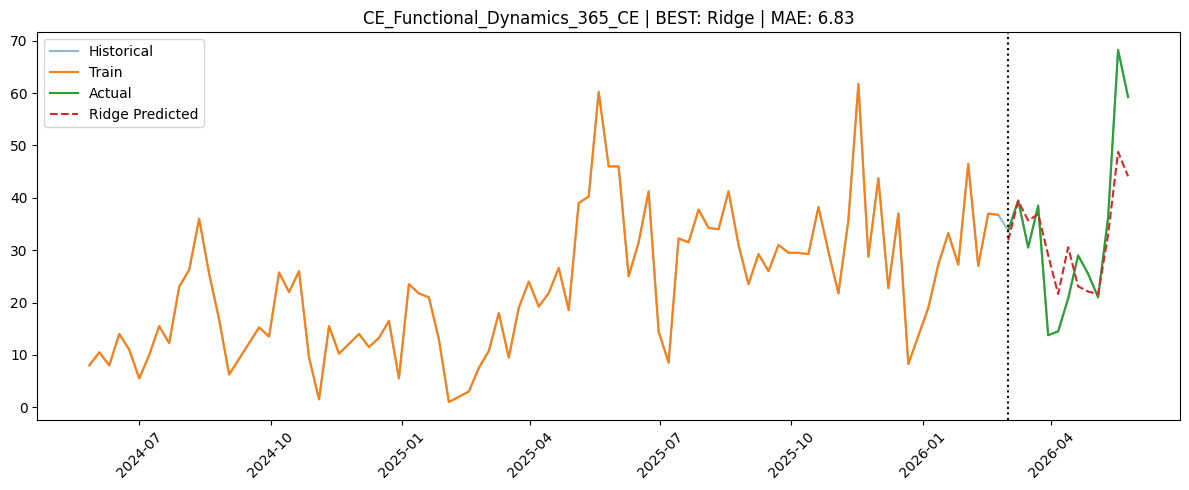


CE_Functional_Dynamics_365_FO | BEST: Ridge | MAPE: 1.16 | MAE: 5.04


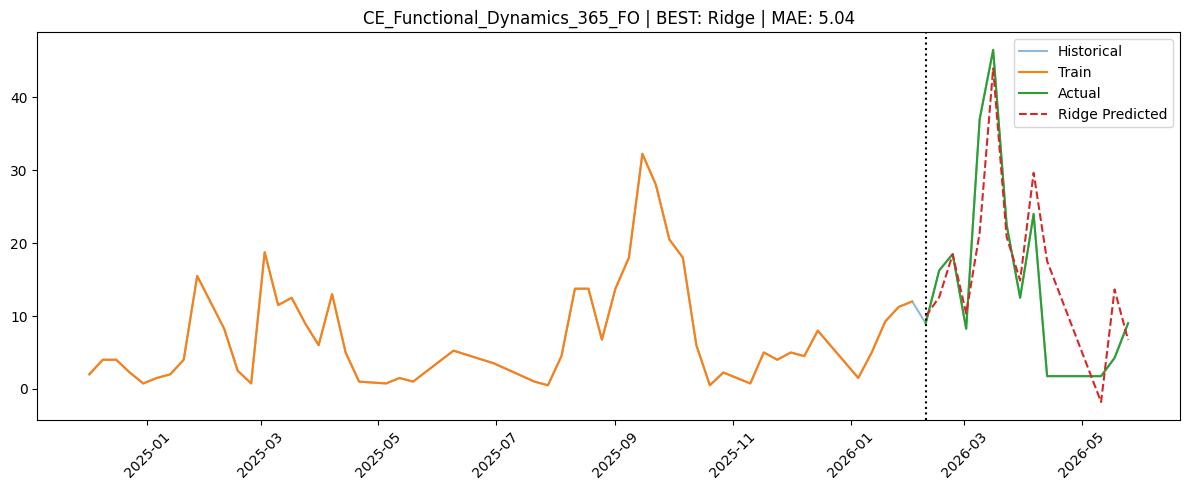

CE_Functional_Dynamics_365_FSCM
CE_Functional_Microsoft_Azure
CE_Functional_Microsoft_Cloud_Data_Warehouse

CE_Functional_Power_Platform | BEST: ExtraTrees | MAPE: 0.35 | MAE: 2.38


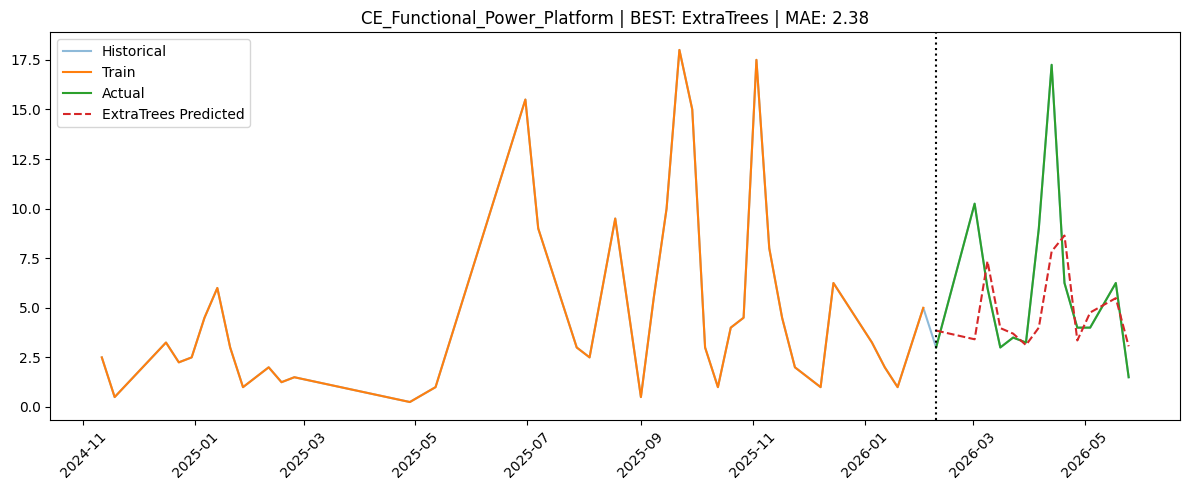


CE_Technical_Dynamics_365_CE | BEST: BayesianRidge | MAPE: 0.17 | MAE: 17.36


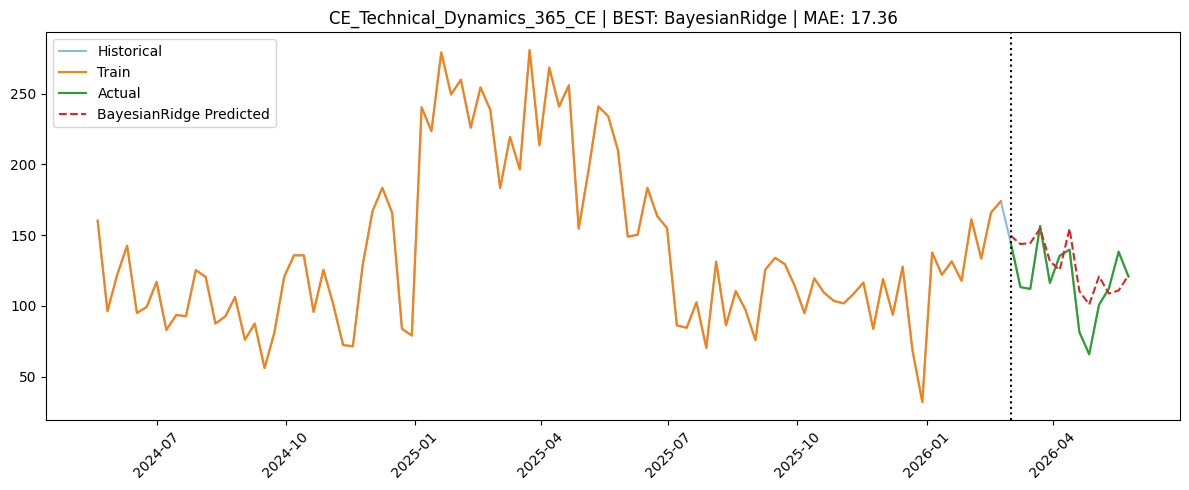


CE_Technical_Dynamics_365_FO | BEST: Lasso | MAPE: 0.20 | MAE: 5.13


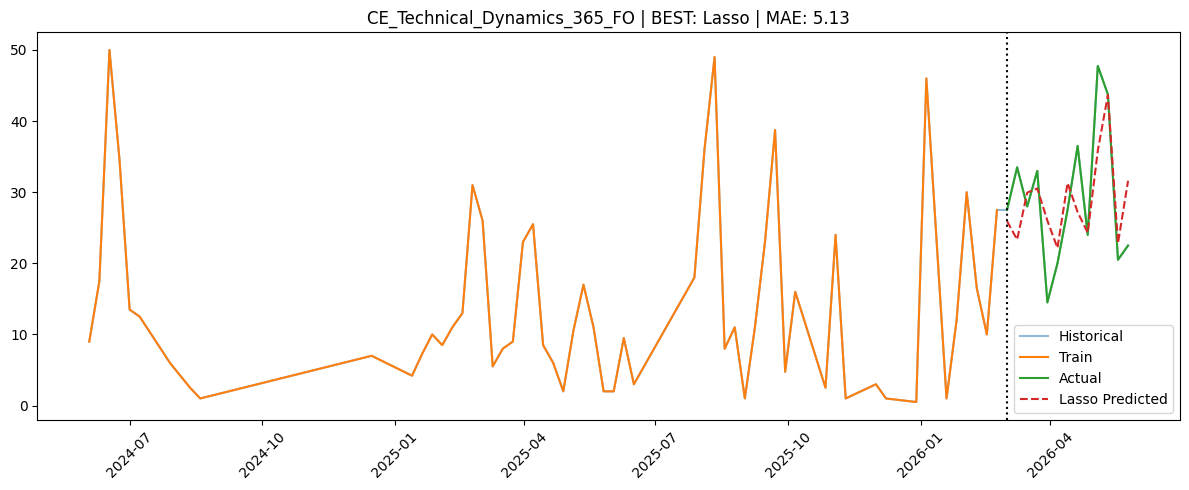

CE_Technical_Dynamics_365_FSCM

CE_Technical_Microsoft_Azure | BEST: BayesianRidge | MAPE: 1.08 | MAE: 1.90


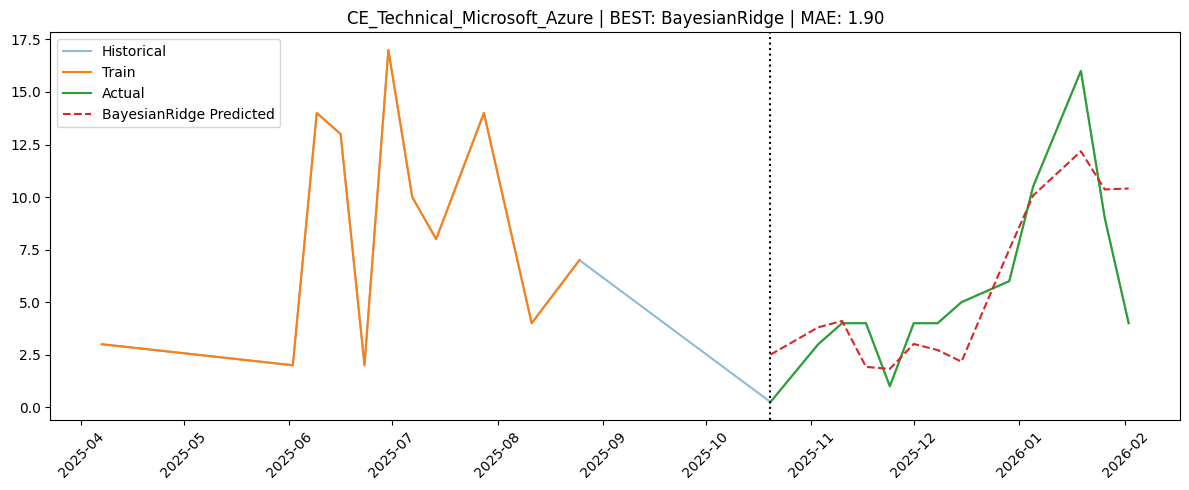


CE_Technical_Microsoft_Cloud_Data_Warehouse | BEST: Lasso | MAPE: 1.38 | MAE: 1.90


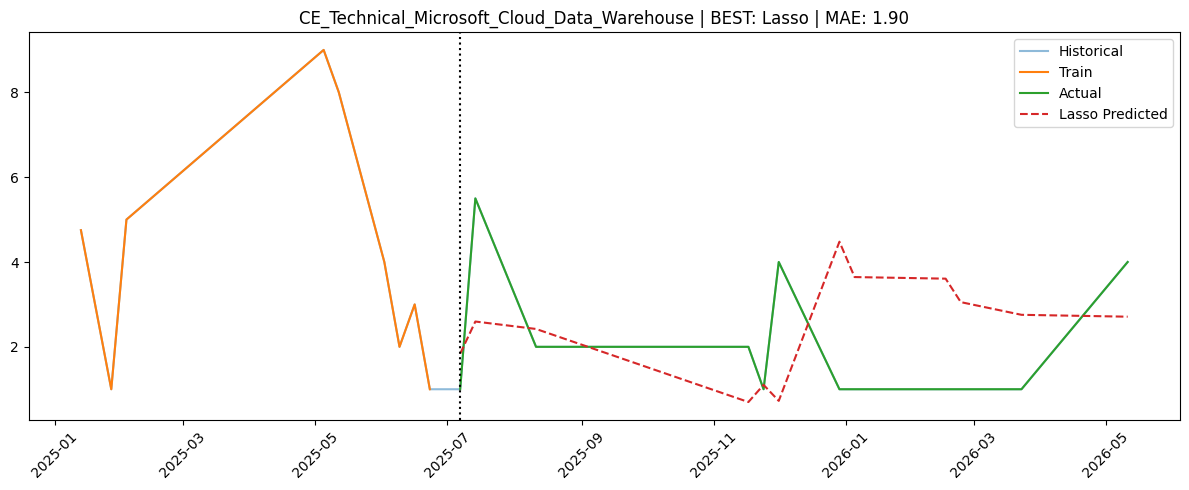


CE_Technical_Power_Platform | BEST: Huber | MAPE: 0.59 | MAE: 3.36


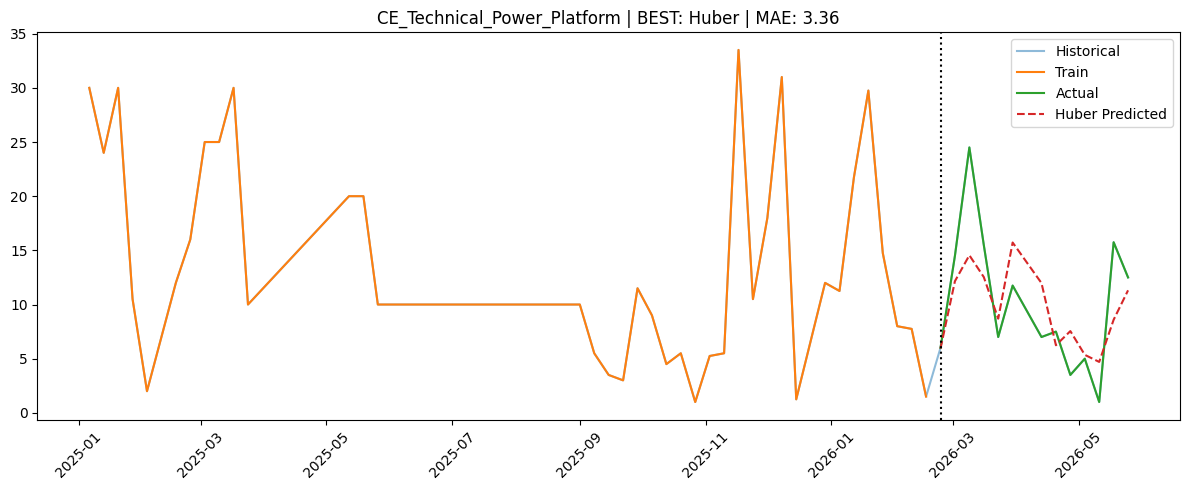


Data_Dynamics_365_BC | BEST: GradientBoosting | MAPE: 0.63 | MAE: 5.04


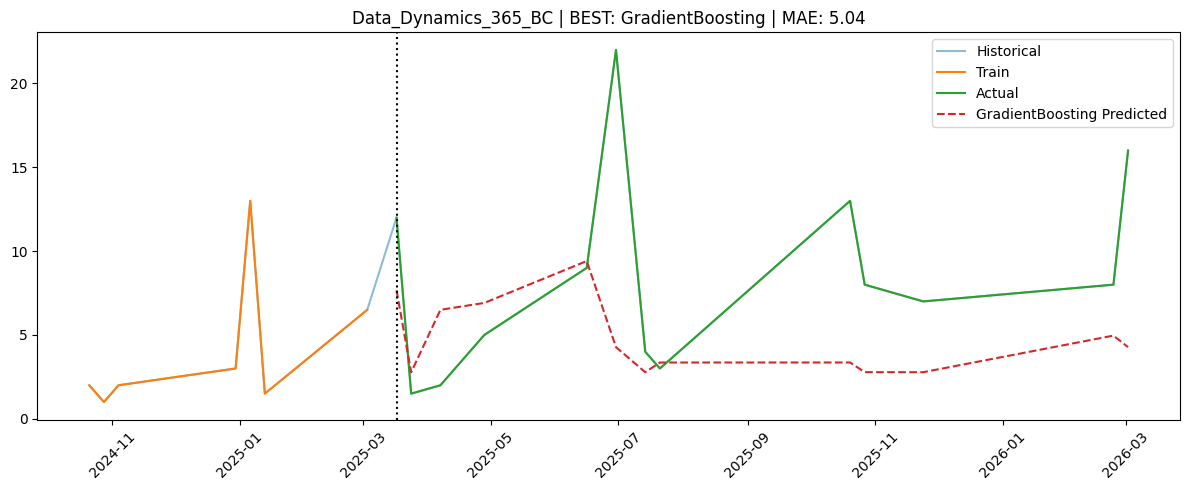


Data_Dynamics_365_CE | BEST: Huber | MAPE: 0.77 | MAE: 9.84


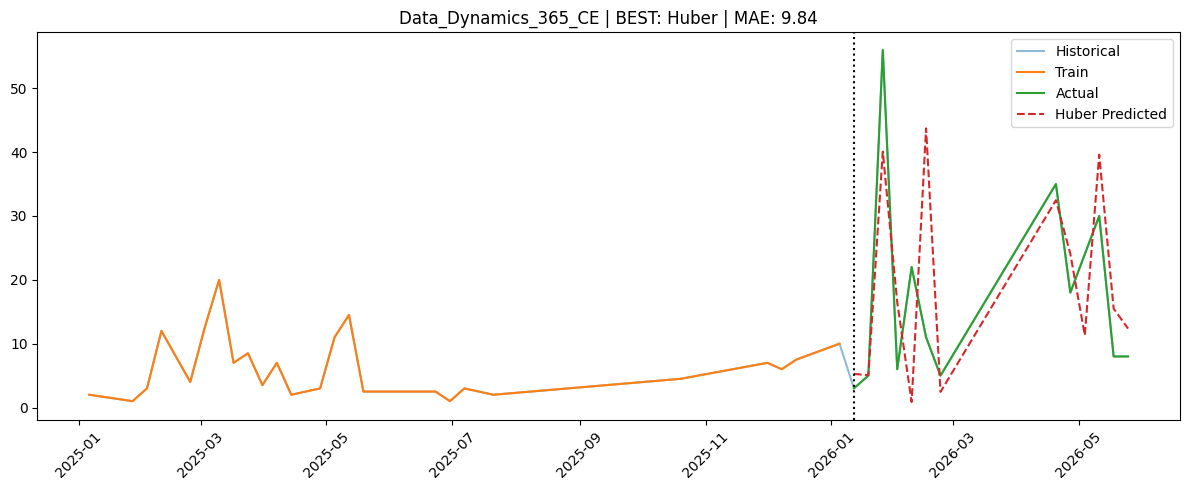


Data_Dynamics_365_FO | BEST: Huber | MAPE: 3.34 | MAE: 9.82


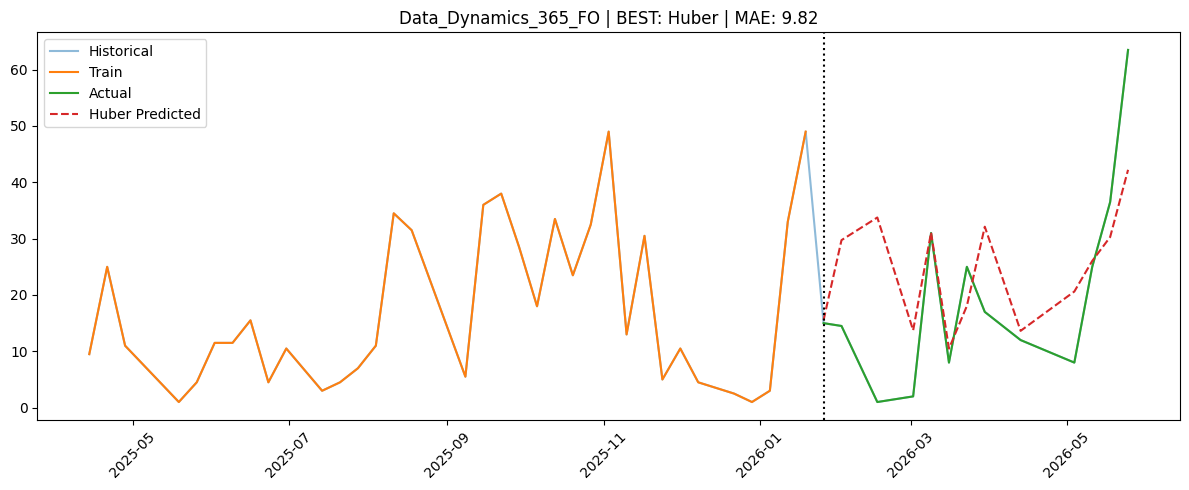

Data_Microsoft_Azure

Data_Microsoft_Cloud_Data_Warehouse | BEST: BayesianRidge | MAPE: 0.61 | MAE: 10.86


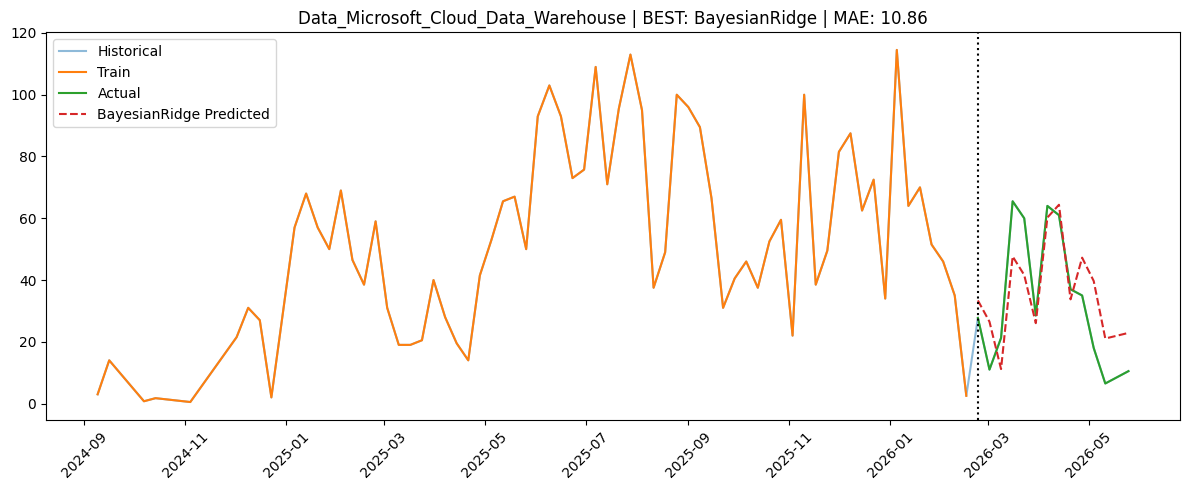


FO_Functional_Dynamics_365_CE | BEST: XGBoost | MAPE: 0.58 | MAE: 0.94


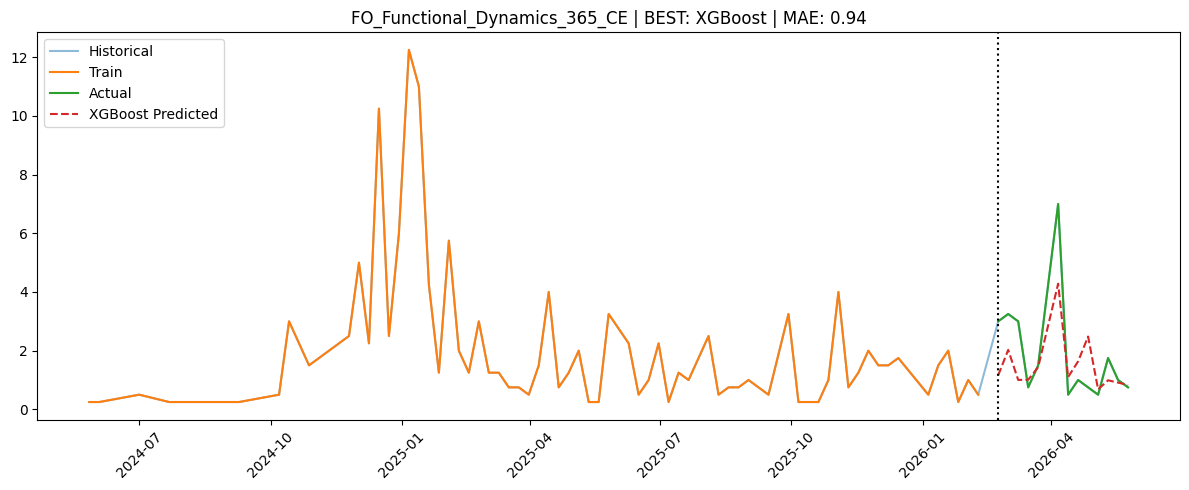


FO_Functional_Dynamics_365_FO | BEST: Lasso | MAPE: 0.13 | MAE: 27.68


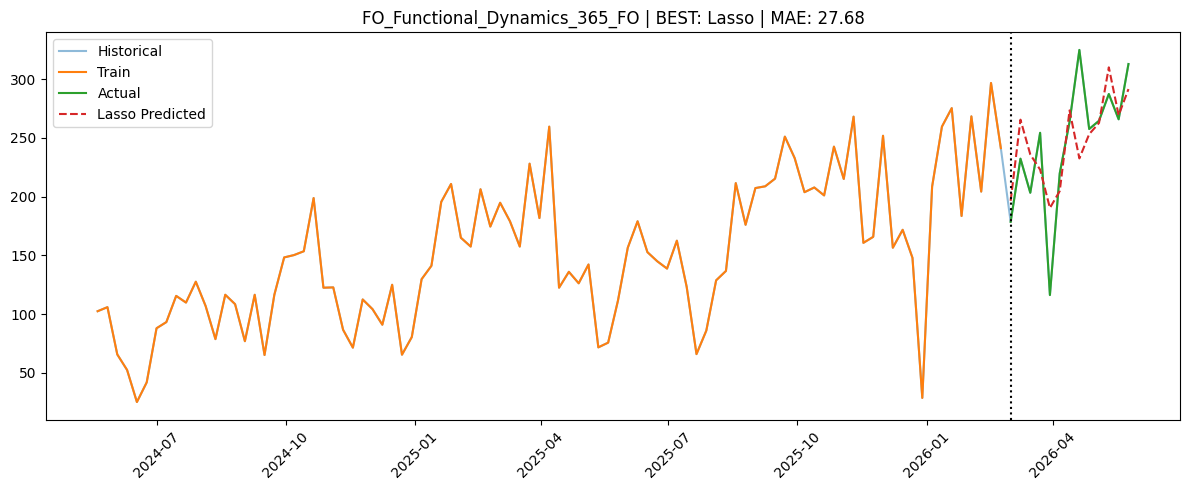


FO_Functional_Dynamics_365_FSCM | BEST: Huber | MAPE: 6.44 | MAE: 4.91


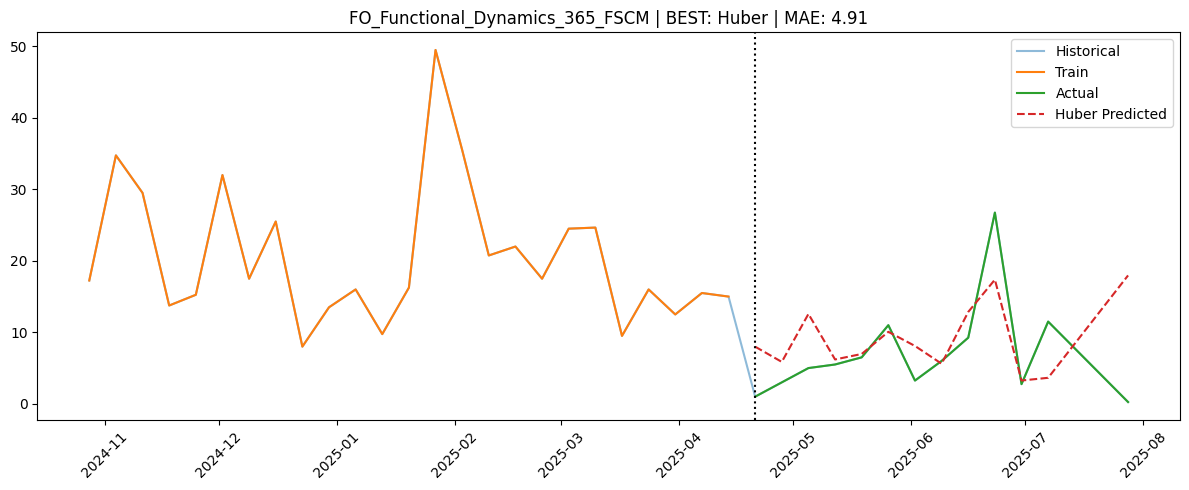


FO_Functional_Microsoft_Azure | BEST: Lasso | MAPE: 0.50 | MAE: 2.35


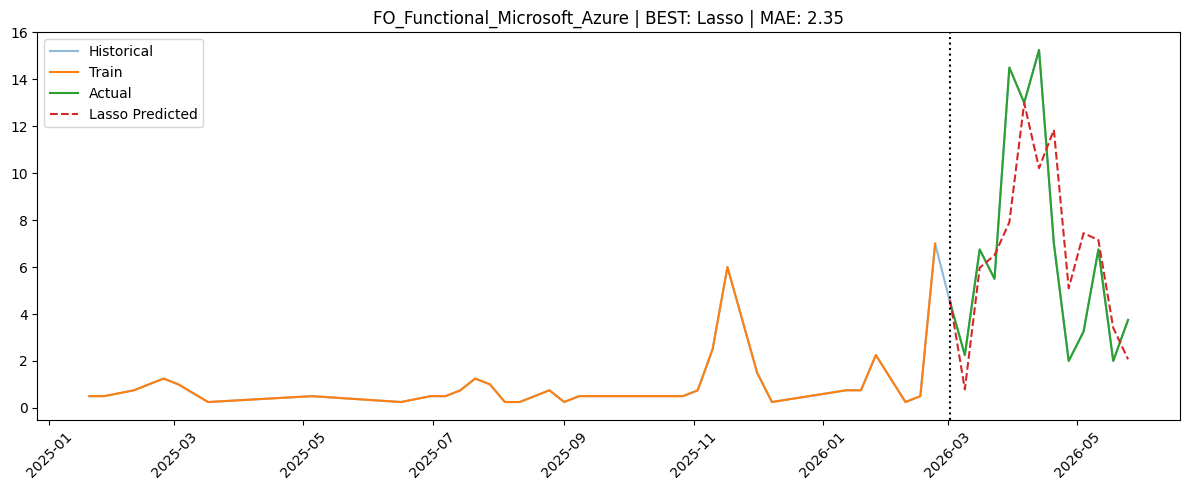


FO_Functional_Microsoft_Cloud_Data_Warehouse | BEST: XGBoost | MAPE: 0.50 | MAE: 0.21


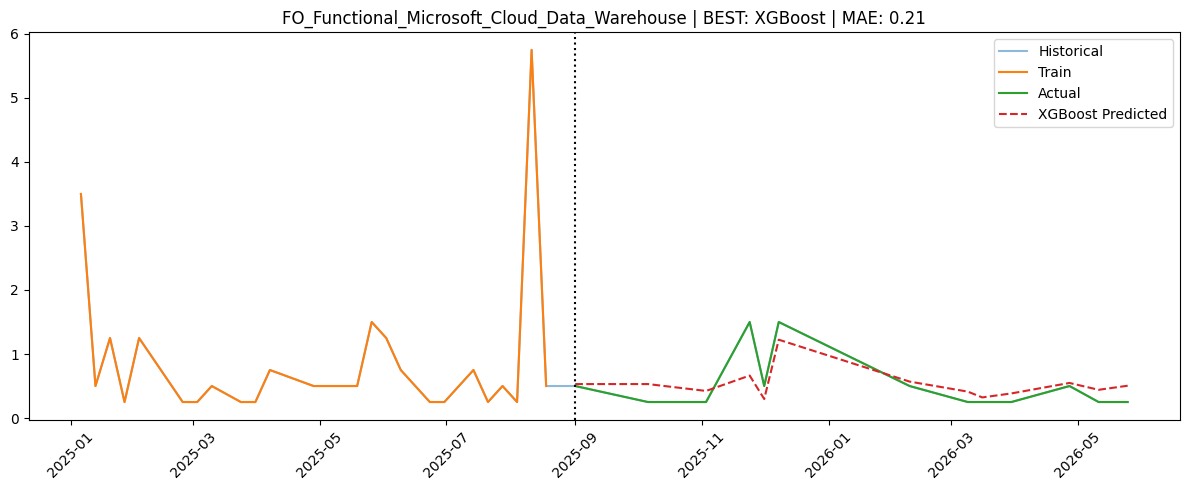

FO_Functional_Power_Platform

FO_Technical_Dynamics_365_CE | BEST: Ridge | MAPE: 1.41 | MAE: 3.16


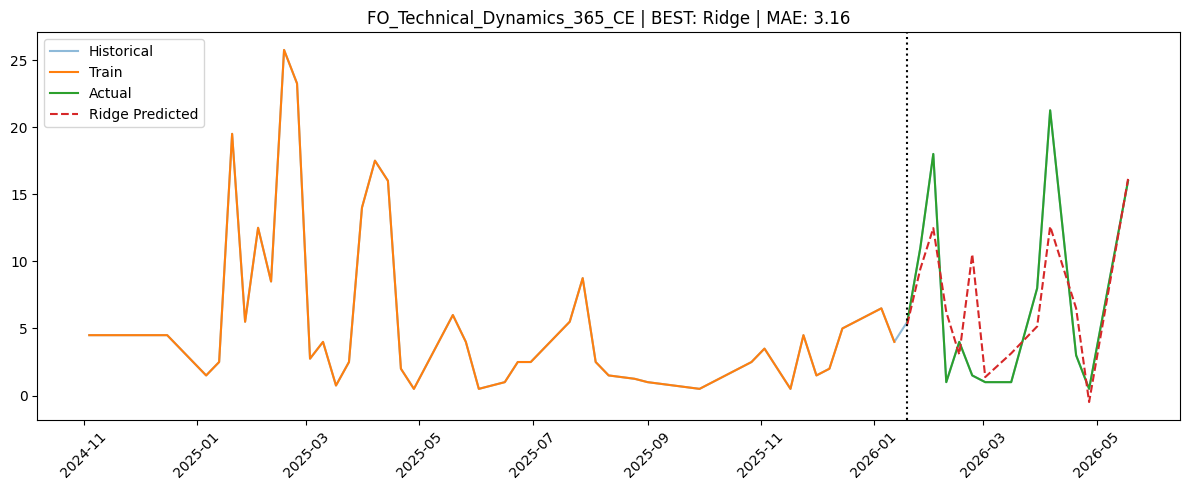


FO_Technical_Dynamics_365_FO | BEST: AdaBoost | MAPE: 0.11 | MAE: 20.44


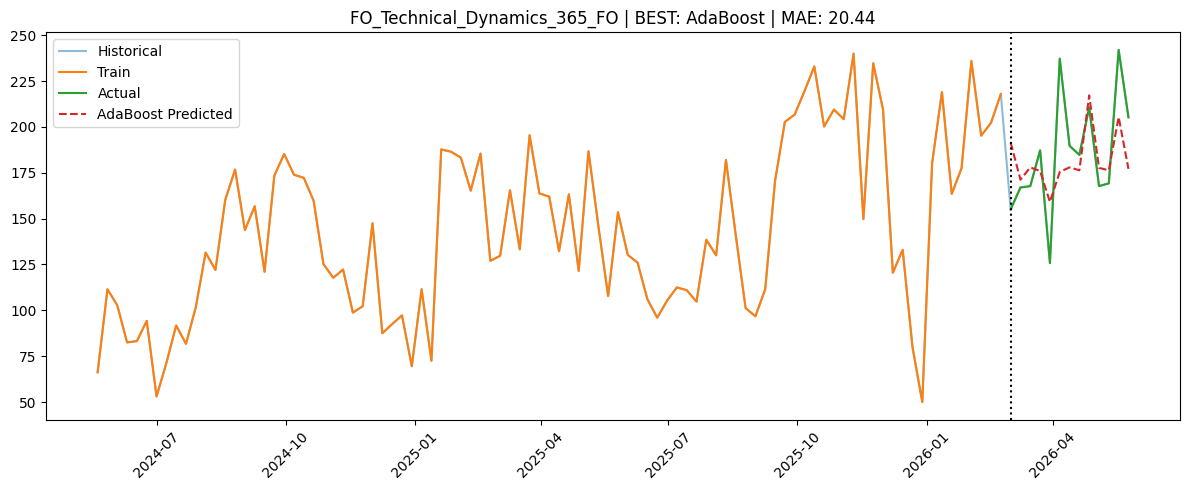


FO_Technical_Dynamics_365_FSCM | BEST: ElasticNet | MAPE: 1.22 | MAE: 2.93


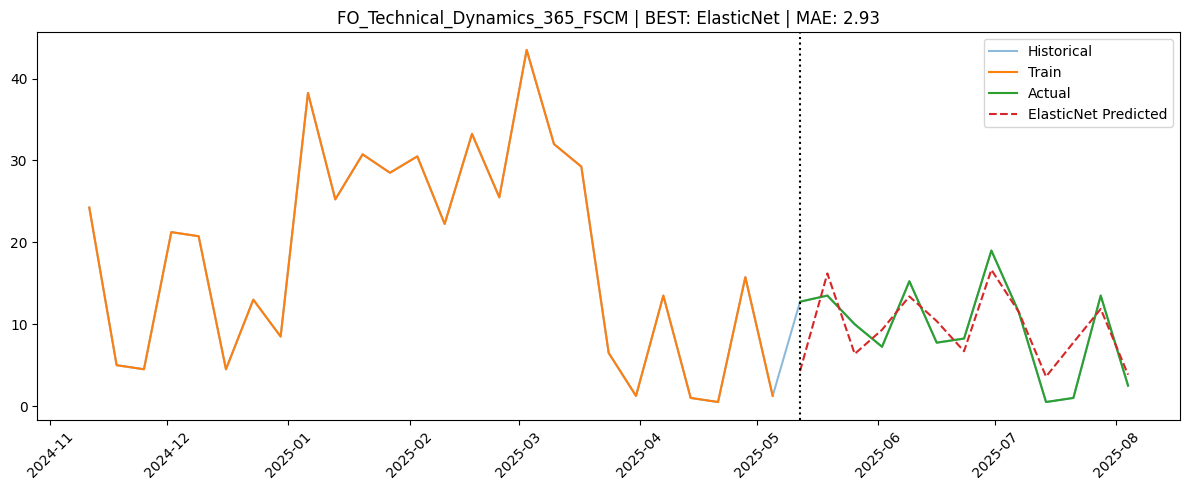


FO_Technical_Microsoft_Azure | BEST: Huber | MAPE: 0.67 | MAE: 2.09


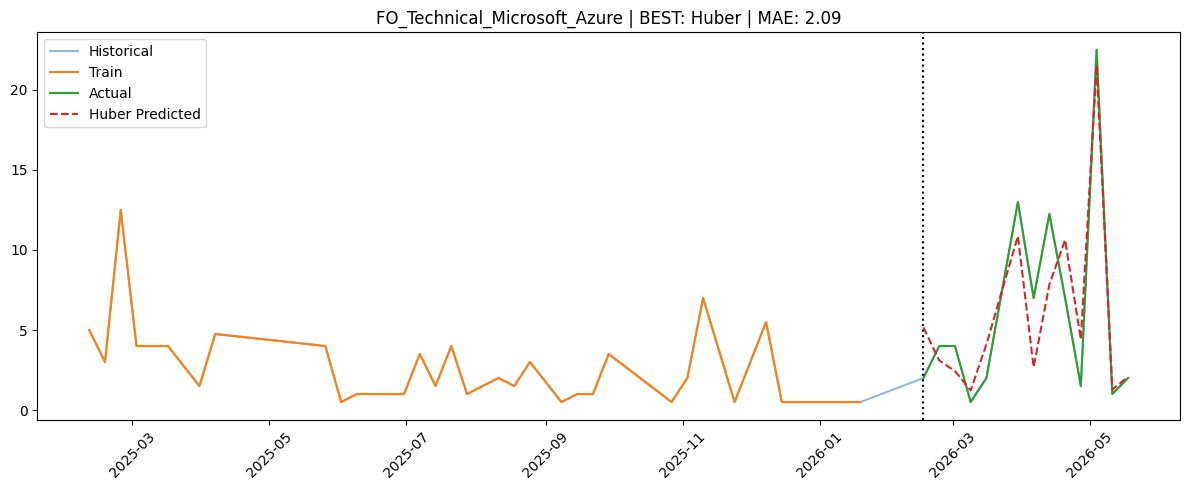

FO_Technical_Microsoft_Cloud_Data_Warehouse
FO_Technical_Power_Platform
SDM_Dynamics_365_BC

SDM_Dynamics_365_FO | BEST: Lasso | MAPE: 0.47 | MAE: 3.09


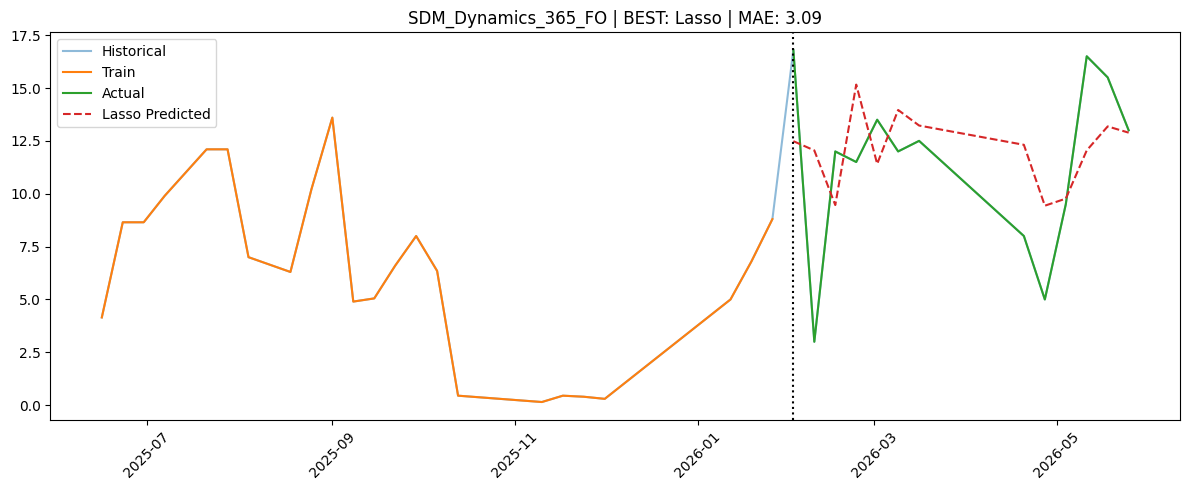

SDM_Dynamics_NAV
SDM_Microsoft_Cloud_Data_Warehouse
SDM_Microsoft_Cloud_Support_Infrastructure
SDM_Power_Platform


,model,MAE,n_obs,best_params
group,,,,
Azure_Infrastructure_Dynamics_365_FO,Ridge,2.027987,34,{'alpha': 10}
Azure_Integration_Dynamics_365_CE,DecisionTree,3.687729,79,{'max_depth': 3}
Azure_Integration_Dynamics_365_FO,Huber,6.087165,106,{'epsilon': 1.5}
Azure_Integration_Dynamics_365_FSCM,RandomForest,1.736628,20,"{'n_estimators': 500, 'max_depth': 3}"
Azure_Integration_Dynamics_NAV,AdaBoost,3.484249,41,{'n_estimators': 500}
Azure_Integration_Microsoft_Azure,BayesianRidge,5.061762,79,"{'lambda_1': 1e-06, 'alpha_1': 1e-05}"
BC_Technical_Dynamics_365_BC,GradientBoosting,3.313851,100,"{'n_estimators': 100, 'learning_rate': 0.1}"
BC_Technical_Dynamics_NAV,Ridge,5.538728,97,{'alpha': 0.1}
CE_Functional_Dynamics_365_CE,Ridge,6.832627,101,{'alpha': 10}


In [33]:
results_list = []

for i in grouped_dfs:
    df_group = grouped_dfs[i].copy()

    if "week" in df_group.columns:
        df_group = df_group.sort_values("week")

    df_group["lag_1"] = df_group["Time worked"].shift(1)
    df_group["lag_2"] = df_group["Time worked"].shift(2)
    df_group["rolling_4"] = df_group["Time worked"].rolling(4).mean()
    df_group = df_group.dropna()

    if len(df_group) < 20:
        print(i)
        continue

    y = df_group["Time worked"]
    X = df_group.drop(columns=["Time worked", "week"], errors="ignore")

    # Drop constant columns
    X = X.loc[:, X.nunique() > 1]

    test_size = 13

    split_idx = len(df_group) - test_size


    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    tscv = TimeSeriesSplit(n_splits=5)
    models = {

        # Linear
        "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1, 10]}),
        "Lasso": (Lasso(), {"alpha": [0.01, 0.1, 1]}),
        "ElasticNet": (ElasticNet(), {"alpha": [0.01, 0.1, 1]}),

        "BayesianRidge": (BayesianRidge(), {
            "alpha_1": [1e-6, 1e-5],
            "lambda_1": [1e-6, 1e-5]
        }),

        "Huber": (HuberRegressor(), {
            "epsilon": [1.1, 1.35, 1.5]
        }),


        # Tree-based
        "DecisionTree": (DecisionTreeRegressor(), {
            "max_depth": [3, 5, 10]
        }),

        "RandomForest": (RandomForestRegressor(random_state=42), {
            "n_estimators": [100, 200, 500],
            "max_depth": [3, 5, 10]
        }),

        "ExtraTrees": (ExtraTreesRegressor(), {
            "n_estimators": [100, 200, 500],
        }),

        "GradientBoosting": (GradientBoostingRegressor(), {
            "n_estimators": [100, 200, 500],
            "learning_rate": [0.05, 0.1]
        }),

        "AdaBoost": (AdaBoostRegressor(), {
            "n_estimators": [100, 200, 500],
        }),

        # Boosting SOTA
        "XGBoost": (XGBRegressor(), {
            "n_estimators": [100, 200, 500],
            "max_depth": [3, 5],
            "learning_rate": [0.05, 0.1]
        }),

        "LightGBM": (LGBMRegressor(verbosity=-1), {
            "n_estimators": [100, 200, 500],
            "num_leaves": [15, 31],
            "learning_rate": [0.05, 0.1]
        }),

        # Others
        "SVR": (SVR(), {
            "C": [0.1, 1, 10]
        }),

        "KNN": (KNeighborsRegressor(), {
            "n_neighbors": [3, 5, 7]
        }),
    }

    best_model = None
    best_preds = None
    best_mae = float("inf")
    best_mape = float("inf")
    best_name = None

    for name, (model, param_grid) in models.items():
        try:
            search = RandomizedSearchCV(
                model,
                param_distributions=param_grid,
                n_iter=20,
                cv=tscv,
                scoring="neg_mean_absolute_error",
                random_state=42,
                n_jobs=-1
            )

            search.fit(X_train, y_train)

            best_estimator = search.best_estimator_
            preds = best_estimator.predict(X_test)

            mae = mean_absolute_error(y_test, preds)
            mape = mean_absolute_percentage_error(y_test, preds)

            # Store all model results
            results_list.append({
                "group": i,
                "model": name,
                "MAE": mae,
                #"MAPE": mape,
                "n_obs": len(df_group),
                "best_params": search.best_params_
            })

            if mae < best_mae:
                best_mape = mape
                best_mae = mae
                best_model = best_estimator
                best_preds = preds
                best_name = name

        except Exception as e:
            print(f"{i} | {name} failed: {e}")

    print(f"\n{i} | BEST: {best_name} | MAPE: {best_mape:.2f} | MAE: {best_mae:.2f}")

    plt.figure(figsize=(12, 5))

    if "week" in df_group.columns:
        weeks = df_group["week"]

        plt.plot(weeks, y, label="Historical", alpha=0.5)
        plt.plot(weeks[:split_idx], y_train, label="Train")
        plt.plot(weeks[split_idx:], y_test, label="Actual")
        plt.plot(weeks[split_idx:], best_preds,
                 label=f"{best_name} Predicted", linestyle="--")

        plt.axvline(weeks.iloc[split_idx], color="black", linestyle=":")
        plt.xticks(rotation=45)

    else:
        idx = np.arange(len(y))

        plt.plot(idx, y, label="Historical", alpha=0.5)
        plt.plot(idx[:split_idx], y_train, label="Train")
        plt.plot(idx[split_idx:], y_test, label="Actual")
        plt.plot(idx[split_idx:], best_preds,
                 label=f"{best_name} Predicted", linestyle="--")

        plt.axvline(split_idx, color="black", linestyle=":")

    plt.title(f"{i} | BEST: {best_name} | MAE: {best_mae:.2f}")
    plt.legend()
    plt.tight_layout()
    plt.show()


results_df = pd.DataFrame(results_list)

results_df = results_df.sort_values(["group", "MAE"])
display(results_df.groupby("group").first())

results_df.to_csv(
    f"experiment_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv",
    index=False
)
